In [112]:
"""
Sigma(E) and M(E) Non-Hermiticity Analysis with respect to condition numbers
===================================
Loads Sigma matrices for indices 95-105, computes non-Hermiticity metrics,
and plots how they evolve across energy index.
Run cell by cell in Jupyter.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


import os

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

folder = Path("/scratch/yimili/matrices")
name       = "si-bulk"   # <-- change to "carbon-chain" or "carbon-nanotube"

# Create output subfolder named after the material, relative to the notebook
output_dir = Path(name)
output_dir.mkdir(parents=True, exist_ok=True)

indices    = list(range(0, 402))  # 95 to 105 inclusive
idx_arr = np.array(indices)

offset2 = 0.005
res = 0.005
materials  = ["carbon-nanotube", "carbon-chain", "si-bulk", "graphene"]
band_edges = [-3.6, -2.4, -2.4, -2.4]

band_edge = band_edges[materials.index(name)]
energies  = band_edge -1 - offset2 + res * idx_arr.astype(float)
print(energies[-1])

-1.4


In [113]:
H = np.load(folder / name / f"H.npy")
S = np.load(folder / name / f"S.npy")

max_singular_values = np.load(folder / name / "max_singular_values.npy")
min_singular_values = np.load(folder / name / "min_singular_values.npy")

condition_numbers = max_singular_values/min_singular_values

kappa = np.load(folder / name / "condition_full_svd.npy")
"""
# ---------------------------------------------------------------------------
# Load all M(E) matrices
# ---------------------------------------------------------------------------
M = {}
for idx in indices:
    path = folder / name / f"M_E_{idx}.npy"
    M[idx] = np.load(path)

# ---------------------------------------------------------------------------
# Load all Sigma(E) matrices
# ---------------------------------------------------------------------------
Sig = {}
for idx in indices:
    path = folder / name / f"Sigma_E_{idx}.npy"
    Sig[idx] = np.load(path)
    
# ---------------------------------------------------------------------------
# Load all rhs(E) matrices
# ---------------------------------------------------------------------------
rhs = {}
for idx in indices:
    path = folder / name / f"rhs_E_{idx}.npy"
    rhs[idx] = np.load(path)

# ---------------------------------------------------------------------------
# Load all spectrum(E) matrices
# ---------------------------------------------------------------------------
"""
w = {}
for idx in indices:
    path = folder / name / f"spectrum_M_E_{idx}.npy"
    w[idx] = np.load(path)

#M_arr   = np.array([M[idx]   for idx in indices])
#Sig_arr = np.array([Sig[idx] for idx in indices])
#rhs_arr = np.array([rhs[idx] for idx in indices])
w_arr   = np.array([w[idx]   for idx in indices])

"""
Sigma_arr_left = Sig_arr[:, :32, :32]
Sigma_arr_right = Sig_arr[:, -32:, -32:]

print(M_arr.shape)    # (n_energies, n, n)
print(Sig_arr.shape)    # (n_energies, n, n)
"""
#print(rhs_arr.shape)  # (n_energies, n) or (n_energies, n, k)
print(w_arr.shape)    # (n_energies, n)

(402, 3840)


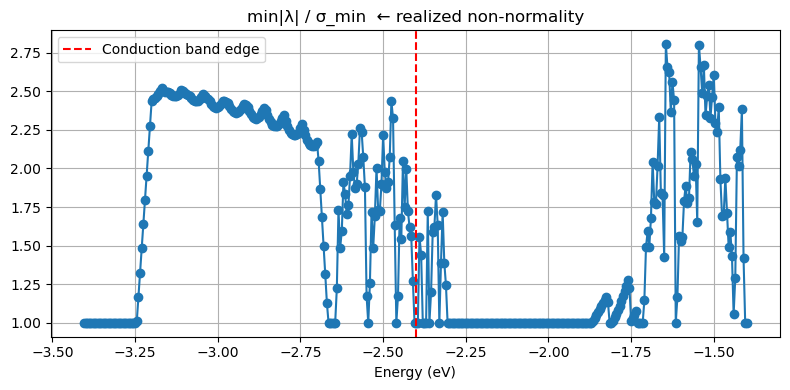

In [114]:
fig, ax = plt.subplots(figsize=(8, 4))

min_abs_eig_arr = np.min(np.abs(w_arr), axis=1)  # shape (402,)
eig_sigma_gap   = min_abs_eig_arr / (min_singular_values + 1e-300)

ax.plot(energies, eig_sigma_gap, "o-")
ax.axvline(band_edge, color="red", linestyle="--", label="Conduction band edge")
ax.set_title("min|λ| / σ_min  ← realized non-normality")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "eig_sigma_gap.png", dpi=150, bbox_inches="tight")
plt.show()

In [80]:
def _fnorm(X):
    """Fast Frobenius norm — avoids internal matmul in np.linalg.norm."""
    return np.sqrt((X.real**2 + X.imag**2).sum())

def hermitian_metrics(A, w_A=None):
    frob_A = _fnorm(A)
    n = A.shape[0]
    Ah = A.conj().T
    
    # Hermitian and anti-Hermitian parts
    H_part  = (A + Ah) / 2
    K_part  = (A - Ah) / (2j)
    
    # 1. Max absolute deviation from Hermitian
    diff          = A - Ah
    max_dev       = np.max(np.abs(diff))
    rel_dev       = max_dev / (frob_A + 1e-300)
    
    # 2. Frobenius norm of anti-Hermitian part
    frob_antiherm = _fnorm(diff) / 2
    
    # 2b. Diagonal contribution to anti-Hermiticity
    diag_antiherm      = np.diag(np.diag(diff) / 2)
    frob_diag_antiherm = _fnorm(diag_antiherm)
    diag_ratio         = frob_diag_antiherm / (frob_antiherm + 1e-300)
    
    # 3. Eigenvalues — use precomputed if provided, otherwise compute
    if w_A is None:
        print("Here")
        w_A = np.linalg.eigvals(A)   # cheaper than eig() since we skip eigenvectors
    
    # 3b. Imaginary parts of the eigenvalues
    min_abs_A_imag = np.min(np.abs(w_A.imag))
    max_abs_A_imag = np.max(np.abs(w_A.imag))
    
    # 3c. Eigenvector condition number — skipped (no eigenvectors computed)
    kappa_V = np.nan
    
    # 3d. Henrici's departure from normality
    dep_norm     = np.sqrt(max(frob_A**2 - np.sum(np.abs(w_A)**2), 0.0))
    dep_norm_rel = dep_norm / (frob_A + 1e-300)
    
    # 3e. Smallest |eigenvalue|
    min_abs_eig = np.min(np.abs(w_A))
    
    # 6. Non-normality
    comm          = A @ Ah - Ah @ A
    non_normality = np.linalg.norm(comm, 'fro') / (frob_A**2 + 1e-300)
    
    # 7. Ratio of anti-Hermitian to Hermitian spectral weight
    norm_H   = _fnorm(H_part)
    norm_K   = _fnorm(K_part)
    ratio_KH = norm_K / (norm_H + 1e-300)
    
    return {
        "frob_A":             frob_A,
        "max_dev":            max_dev,
        "rel_dev":            rel_dev,
        "frob_antiherm":      frob_antiherm,
        "frob_diag_antiherm": frob_diag_antiherm,
        "diag_ratio":         diag_ratio,
        "w_A":                w_A,
        "min_abs_A_imag":     min_abs_A_imag,
        "max_abs_A_imag":     max_abs_A_imag,
        "kappa_V":            kappa_V,       # nan — not computed
        "dep_norm":           dep_norm,
        "dep_norm_rel":       dep_norm_rel,
        "min_abs_eig":        min_abs_eig,
        "non_normality":      non_normality,
        "norm_H":             norm_H,
        "norm_K":             norm_K,
        "ratio_KH":           ratio_KH,
        "H_part":             H_part,
        "K_part":             K_part,
    }

In [81]:
def plot_metrics(metrics_dict, indices, energies, idx_arr, name, filename=None):
    min_abs_eig_arr = np.array([metrics_dict[i]["min_abs_eig"] for i in indices])

    fig, axes = plt.subplots(6, 2, figsize=(12, 26))
    fig.suptitle(f"Non-Hermiticity metrics — {name}", fontsize=13)

    def _plot(ax, values, ylabel, title, logy=True):
        ax.plot(energies, values, "o-")
        ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
        ax.set_title(title)
        ax.set_xlabel("Energy (eV)")
        ax.set_ylabel(ylabel)
        if logy and np.all(np.array(values) > 0):
            ax.set_yscale("log")
        ax.grid(True)
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        tick_energies = energies[::len(energies)//6]
        tick_indices  = idx_arr[::len(idx_arr)//6]
        ax2.set_xticks(tick_energies)
        ax2.set_xticklabels(tick_indices)
        ax2.set_xlabel("Index")
        ax2.xaxis.set_label_position("bottom")
        ax2.xaxis.tick_bottom()
        ax2.spines["bottom"].set_position(("outward", 30))

    _plot(axes[0, 0], [metrics_dict[i]["frob_A"]         for i in indices], "", "‖A‖_F")
    _plot(axes[0, 1], [metrics_dict[i]["max_dev"]        for i in indices], "", "Max |A - A†|")
    _plot(axes[1, 0], [metrics_dict[i]["rel_dev"]        for i in indices], "", "Relative deviation")
    _plot(axes[1, 1], [metrics_dict[i]["frob_antiherm"]  for i in indices], "", "‖anti-Herm part‖_F")
    _plot(axes[2, 0], [metrics_dict[i]["diag_ratio"]     for i in indices], "", "Diag / ‖anti-Herm‖_F", logy=False)
    _plot(axes[2, 1], [metrics_dict[i]["min_abs_A_imag"] for i in indices], "eV", "min |eig(A).imag|  ← Lorentzian floor")
    _plot(axes[3, 0], [metrics_dict[i]["non_normality"]  for i in indices], "", "Non-normality ‖AA†-A†A‖_F / ‖A‖²_F")
    _plot(axes[3, 1], [metrics_dict[i]["ratio_KH"]       for i in indices], "", "‖K‖_F / ‖H‖_F")
    _plot(axes[4, 0], [metrics_dict[i]["kappa_V"]        for i in indices], "", "κ(V)  ← eigenvector cond. (worst case)")
    _plot(axes[4, 1], [metrics_dict[i]["dep_norm_rel"]   for i in indices], "", "Henrici dep / ‖A‖_F", logy=False)
    _plot(axes[5, 0], min_abs_eig_arr,                                      "", "min |eig(A)|  (upper bound on σ_min)")
    axes[5, 1].set_visible(False)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

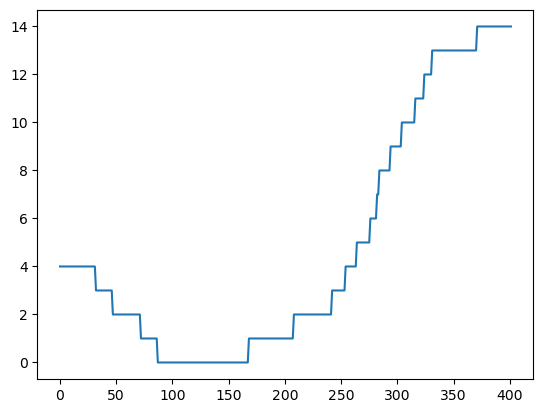

In [82]:
########## Plot rhs shape
plt.plot(idx_arr, [rhs[idx].shape[-1] for idx in idx_arr])
plt.savefig("rhs_shape[-1].png", dpi=150, bbox_inches="tight")

In [83]:
import time

n_trials = 10
idx = indices[0]
times = []

for _ in range(n_trials):
    t0 = time.time()
    hermitian_metrics(M[idx], w_A=w[idx])
    times.append(time.time() - t0)

times = np.array(times)
print(f"mean:   {times.mean():.3f}s")
print(f"std:    {times.std():.3f}s")
print(f"min:    {times.min():.3f}s")
print(f"max:    {times.max():.3f}s")
print(f"median: {np.median(times):.3f}s")

mean:   0.223s
std:    0.024s
min:    0.193s
max:    0.259s
median: 0.224s


In [84]:
import cProfile
import pstats
import io

pr = cProfile.Profile()
pr.enable()
hermitian_metrics(M[indices[0]], w_A=w[indices[0]])
pr.disable()

s = io.StringIO()
ps = pstats.Stats(pr, stream=s).sort_stats('cumulative')
ps.print_stats(15)  # top 15 lines
print(s.getvalue())

         268 function calls (266 primitive calls) in 0.080 seconds

   Ordered by: cumulative time
   List reduced from 113 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    0.187    0.094 /home/msc26f15/.conda/envs/nla_lab/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3711(run_code)
      3/2    0.000    0.000    0.187    0.094 {built-in method builtins.exec}
        2    0.037    0.018    0.037    0.018 {method 'dot' of 'numpy.ndarray' objects}
        1    0.000    0.000    0.028    0.028 /tmp/ipykernel_2189961/363212432.py:5(hermitian_metrics)
        5    0.020    0.004    0.022    0.004 /tmp/ipykernel_2189961/363212432.py:1(_fnorm)
        1    0.007    0.007    0.020    0.020 /home/msc26f15/.conda/envs/nla_lab/lib/python3.12/site-packages/decorator.py:232(fun)
        1    0.000    0.000    0.019    0.019 /home/msc26f15/.conda/envs/nla_lab/lib/python3.12/site-packages/numpy/linalg

In [62]:
########## Metrics for system matrix M(E)
# ---------------------------------------------------------------------------
# Compute metrics for all indices
# ---------------------------------------------------------------------------

M_E_metrics = {idx: hermitian_metrics(M[idx], w_A=w[idx]) for idx in indices}

KeyboardInterrupt: 

In [89]:
condition_numbers.shape

(402,)